Implement inverse CDF sampling for the Cauchy distribution. The CDF is F(x) = 0.5 + arctan(x)/pi. Generate 10,000 samples and plot the histogram against the true PDF. Notice the heavy tails (extreme values far from center)

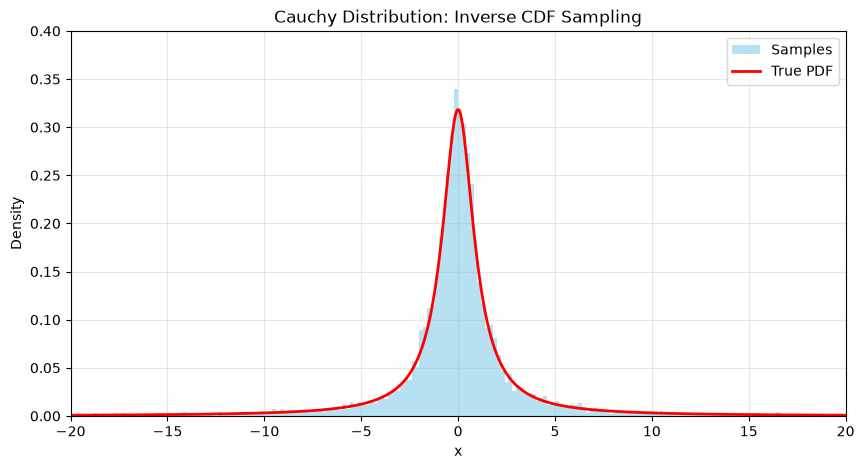

Min sample: -864.5843475849261
Max sample: 7643.001848292321
Std dev: 92.16688032007335


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Generate 10,000 uniform random samples between 0 and 1
u=np.random.uniform(0,1,10000)

# Step 2: Apply inverse CDF formula
# F(x) = 0.5 + arctan(x)/pi
# Solving for x: x = tan(pi * (u - 0.5))
samples=np.tan(np.pi*(u-0.5))

# Step 3: True PDF of Cauchy distribution: f(x) = 1 / (pi * (1 + x^2))

x=np.linspace(-20,20,1000)

pdf=1/(np.pi * (1+ x**2))

plt.figure(figsize=(10, 5))
plt.hist(samples, bins=200, density=True, range=(-20, 20),
         alpha=0.6, color='skyblue', label='Samples')

plt.plot(x, pdf, 'r-', linewidth=2, label='True PDF')
plt.xlim(-20, 20)
plt.ylim(0, 0.4)
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Cauchy Distribution: Inverse CDF Sampling')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Min sample:", samples.min())
print("Max sample:", samples.max())
print("Std dev:", samples.std())

Use rejection sampling to generate samples from a Beta(2, 5) distribution using a Uniform(0, 1) proposal. Plot the accepted samples against the true Beta PDF. What is the theoretical acceptance rate?

M (max of PDF): 2.4575984616935505
Theoretical acceptance rate: 0.4069012963618524
Actual acceptance rate:     0.4085467990358296


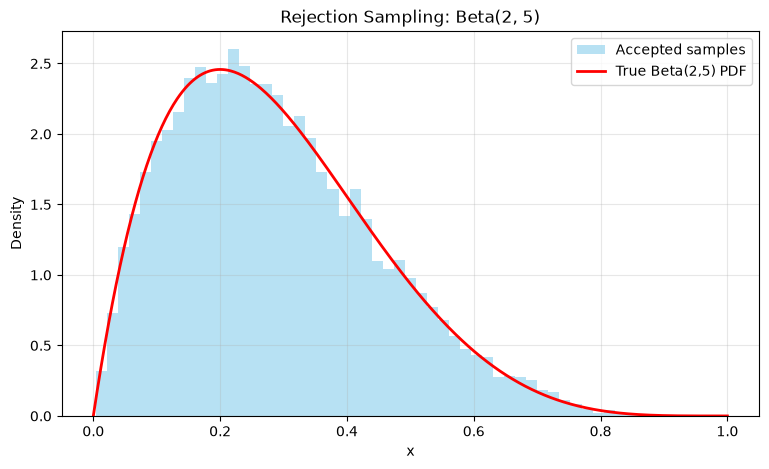

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist
from math import gamma

# Beta(2, 5) PDF: f(x) = x^(a-1) * (1-x)^(b-1) / B(a,b)
a, b = 2, 5

# Normalizing constant B(a,b) = Gamma(a)*Gamma(b)/Gamma(a+b)
B = gamma(a) * gamma(b) / gamma(a + b)

def beta_pdf(x):
    return (x ** (a - 1)) * ((1 - x) ** (b - 1)) / B

# Step 1: Find M — the maximum of the PDF (so M * proposal >= target)
x_grid = np.linspace(0, 1, 1000)
M = beta_pdf(x_grid).max()
print("M (max of PDF):", M)

# Step 2: Rejection sampling loop
np.random.seed(42)
n_samples = 10000
accepted = []

total_tries = 0
while len(accepted) < n_samples:
    # Proposal: Uniform(0,1)
    x = np.random.uniform(0, 1)
    # Accept/reject
    u = np.random.uniform(0, 1)
    if u <= beta_pdf(x) / M:
        accepted.append(x)
    total_tries += 1

accepted = np.array(accepted)

# Step 3: Theoretical acceptance rate
accept_rate_theory = 1 / M
accept_rate_actual = n_samples / total_tries
print("Theoretical acceptance rate:", accept_rate_theory)
print("Actual acceptance rate:    ", accept_rate_actual)

# Step 4: Plot
x = np.linspace(0, 1, 500)
plt.figure(figsize=(9, 5))
plt.hist(accepted, bins=50, density=True, alpha=0.6,
         color='skyblue', label='Accepted samples')
plt.plot(x, beta_pdf(x), 'r-', linewidth=2, label='True Beta(2,5) PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Rejection Sampling: Beta(2, 5)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Estimate the integral of sin(x) from 0 to pi using Monte Carlo with 1,000, 10,000, and 100,000 samples. Compare the error at each level. Verify that the error scales as O(1/sqrt(N)).

N =    1000  Estimate = 1.985972  Error = 0.014028
N =   10000  Estimate = 1.996765  Error = 0.003235
N =  100000  Estimate = 1.996240  Error = 0.003760


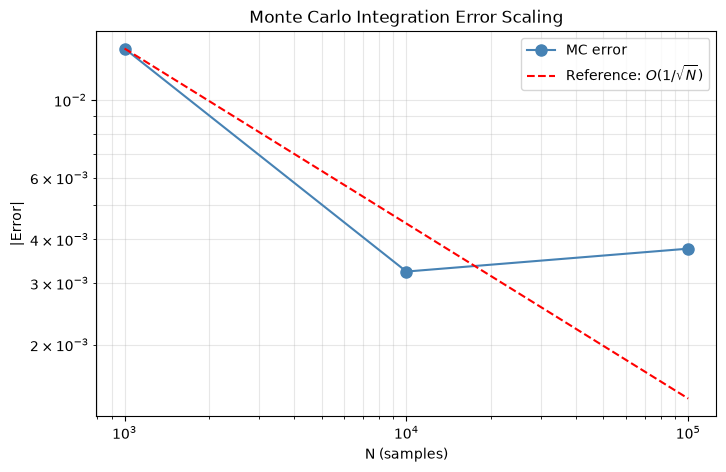

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# True value of integral: ∫ sin(x) dx from 0 to pi = -cos(pi) - (-cos(0)) = 2
true_value = 2.0

# Monte Carlo estimate: average of sin(x) over Uniform(0, pi), times (pi - 0)
def mc_integrate(n):
    x = np.random.uniform(0, np.pi, n)
    return np.pi * np.mean(np.sin(x))

# Run for the three sample sizes
np.random.seed(0)
sizes = [1000, 10000, 100000]
estimates = []
errors = []

for n in sizes:
    est = mc_integrate(n)
    err = abs(est - true_value)
    estimates.append(est)
    errors.append(err)
    print(f"N = {n:>7}  Estimate = {est:.6f}  Error = {err:.6f}")

# Plot error vs N on a log-log plot
plt.figure(figsize=(8, 5))
plt.loglog(sizes, errors, 'o-', color='steelblue',
           markersize=8, label='MC error')

# Reference line ~ 1/sqrt(N) for comparison
ref = errors[0] * np.sqrt(sizes[0]) / np.sqrt(np.array(sizes))
plt.loglog(sizes, ref, 'r--', label=r'Reference: $O(1/\sqrt{N})$')

plt.xlabel('N (samples)')
plt.ylabel('|Error|')
plt.title('Monte Carlo Integration Error Scaling')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()